# JIFLR Pendant Data Analysis Example

This notebook demonstrates how to work with the processed pendant sensor data from the Juneau Icefield Lapse Rate (JIFLR) project using the **new sensor_idx structure**.

The processed data has been refactored (October 2025) to use an efficient structure with dimensions:
- **sensor_idx**: Index for individual sensors (replaces sparse site_id × height × shielding structure)
- **datetime**: Time dimension in local timezone

Sensor metadata is stored as coordinates indexed by sensor_idx:
- **site_id(sensor_idx)**: Site identifiers (A01, A02, B01, etc.)
- **height(sensor_idx)**: Sensor heights (1m, 2m, etc.)
- **shielding(sensor_idx)**: Shielding type (shielded, unshielded)
- **sensor_type(sensor_idx)**: Sensor type (hobo pendant, pace)

Variables include:
- **temp_c**: Temperature in degrees Celsius
- **intensity_lux**: Light intensity in lux (when available)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Set plotting style
plt.style.use('default')

## Load the Data

Load the processed level 1 dataset with the new sensor_idx structure.

In [2]:
# Load the main level 1 dataset with sensor_idx structure
data_path = Path("../data/2025/processed/lvl1/lvl1_combined.nc")
ds = xr.open_dataset(data_path)

print("Dataset structure:")
print(f"Dimensions: {dict(ds.sizes)}")
print(f"Data variables: {list(ds.data_vars.keys())}")
print(f"Coordinates: {list(ds.coords.keys())}")
print()
print("Dataset:")
print(ds)

Dataset structure:
Dimensions: {'datetime': 25578, 'sensor_idx': 66}
Data variables: ['temp_c', 'intensity_lux']
Coordinates: ['datetime', 'sensor_id', 'site_id', 'height', 'shielding', 'sensor_type', 'sensor_generation', 'elevation', 'latitude', 'longitude', 'sensor_idx']

Dataset:
<xarray.Dataset> Size: 27MB
Dimensions:            (datetime: 25578, sensor_idx: 66)
Coordinates:
  * datetime           (datetime) datetime64[ns] 205kB 2025-06-11T15:00:00 .....
  * sensor_idx         (sensor_idx) int64 528B 0 1 2 3 4 5 ... 60 61 62 63 64 65
    sensor_id          (sensor_idx) <U8 2kB ...
    site_id            (sensor_idx) <U9 2kB ...
    height             (sensor_idx) <U4 1kB ...
    shielding          (sensor_idx) <U10 3kB ...
    sensor_type        (sensor_idx) <U12 3kB ...
    sensor_generation  (sensor_idx) <U3 792B ...
    elevation          (sensor_idx) float64 528B ...
    latitude           (sensor_idx) float64 528B ...
    longitude          (sensor_idx) float64 528B ...
Data v

In [3]:
# Explore the sensor metadata coordinates
print("Sensor metadata (first 10 sensors):")
print(f"Site IDs: {ds.site_id.values[:10]}")
print(f"Heights: {ds.height.values[:10]}")
print(f"Shielding: {ds.shielding.values[:10]}")
print(f"Sensor types: {ds.sensor_type.values[:10]}")

print(f"\nUnique sites: {np.unique(ds.site_id.values)}")
print(f"Unique heights: {np.unique(ds.height.values)}")
print(f"Unique shielding types: {np.unique(ds.shielding.values)}")
print(f"Time range: {pd.Timestamp(ds.datetime.values[0])} to {pd.Timestamp(ds.datetime.values[-1])}")
print(f"Total sensors: {len(ds.sensor_idx)}")

Sensor metadata (first 10 sensors):
Site IDs: ['Lee2' 'Lee2' 'Windward1' 'Windward1' 'Windward2' 'Windward2' 'A02'
 'Lee1' 'Lee1' 'Divide']
Heights: ['2m' '2m' '2m' '2m' '2m' '2m' '0.5m' '2m' '2m' '2m']
Shielding: ['unshielded' 'shielded' 'shielded' 'unshield' 'shielded' 'unshield'
 'unshielded' 'shielded' 'unshield' 'unshielded']
Sensor types: ['hobo pendant' 'hobo pendant' 'hobo pendant' 'hobo pendant'
 'hobo pendant' 'hobo pendant' 'hobo pendant' 'hobo pendant'
 'hobo pendant' 'hobo pendant']

Unique sites: ['A01' 'A02' 'A03' 'A04' 'A05' 'A06' 'A07' 'A08' 'A10' 'B01' 'B02' 'B03'
 'C02' 'D01' 'D02' 'D04' 'Divide' 'E01' 'E03' 'E04' 'F03' 'F05' 'F06'
 'G01' 'G02' 'G03' 'G03a' 'G03b' 'G04' 'Lee1' 'Lee2' 'Windward1'
 'Windward2']
Unique heights: ['0.5m' '0m' '1m' '2m']
Unique shielding types: ['shielded' 'unshield' 'unshielded']
Time range: 2025-06-11 15:00:00 to 2025-09-08 10:25:00
Total sensors: 66


## Example 1: Temperature Time Series for a Single Site

Plot temperature data for all sensors at a specific site using the new sensor_idx structure.

Data for site A04:
Number of sensors: 2
Available heights: [np.str_('1m'), np.str_('2m')]
Sensor types: [np.str_('hobo pendant'), np.str_('hobo pendant')]


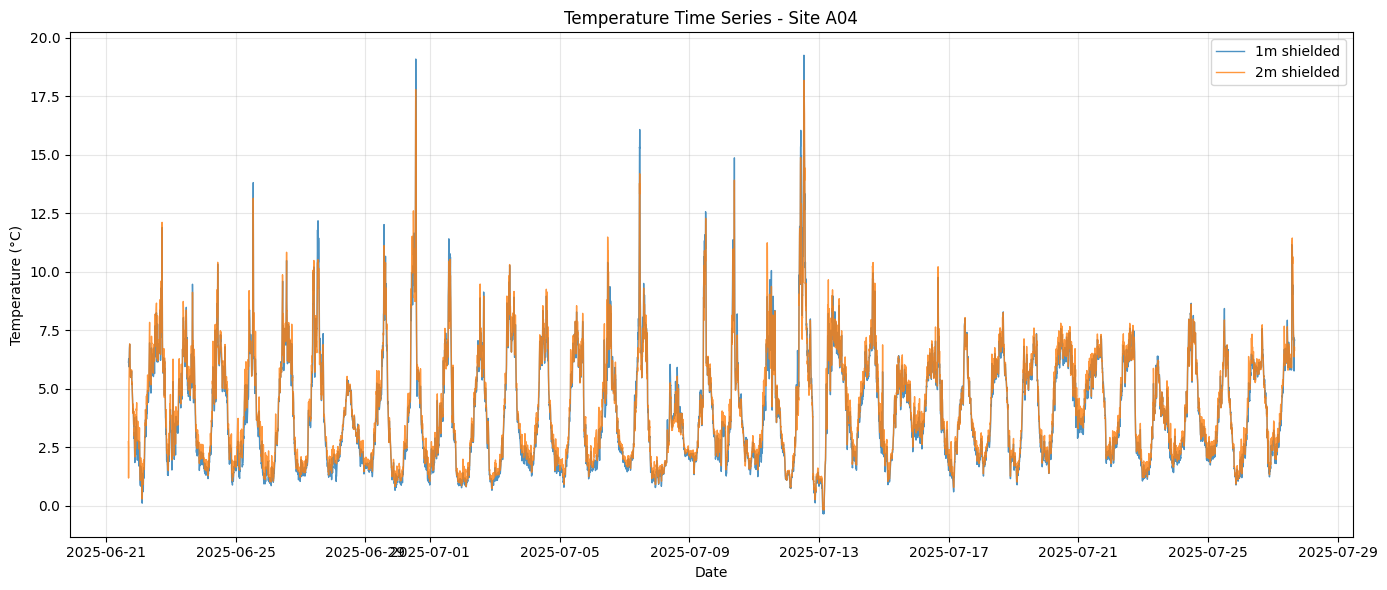

In [4]:
# Select a site to analyze
site_name = "A04"  # Change this to any available site

# Use ds.where() to filter sensors at this site
site_data = ds.where(ds.site_id == site_name, drop=True)

print(f"Data for site {site_name}:")
print(f"Number of sensors: {len(site_data.sensor_idx)}")
print(f"Available heights: {list(site_data.height.values)}")
print(f"Sensor types: {list(site_data.sensor_type.values)}")

# Plot temperature data for each sensor at this site
fig, ax = plt.subplots(figsize=(14, 6))

for sensor_idx in range(len(site_data.sensor_idx)):
    temp_data = site_data.temp_c.isel(sensor_idx=sensor_idx).dropna("datetime")
    if len(temp_data) > 0:
        height = site_data.height.values[sensor_idx]
        shielding = site_data.shielding.values[sensor_idx]
        label = f"{height} {shielding}"
        
        ax.plot(temp_data.datetime, temp_data.values, 
                label=label, alpha=0.8, linewidth=1.0)

ax.set_title(f"Temperature Time Series - Site {site_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 2: Multi-Site Temperature Comparison

Compare temperatures across multiple sites at the same height using the new sensor_idx structure.

<xarray.DataArray 'temp_c' (datetime: 25578, sensor_idx: 5)> Size: 1MB
array([[       nan,        nan, 5.14444444,        nan,        nan],
       [       nan,        nan, 4.95777778,        nan,        nan],
       [       nan,        nan, 4.73222222,        nan,        nan],
       ...,
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan]],
      shape=(25578, 5))
Coordinates:
  * datetime           (datetime) datetime64[ns] 205kB 2025-06-11T15:00:00 .....
  * sensor_idx         (sensor_idx) int64 40B 13 37 48 54 64
    sensor_id          (sensor_idx) <U8 160B '22133659' ... '22133646'
    site_id            (sensor_idx) <U9 180B 'D02' 'A03' 'A02' 'D04' 'D01'
    height             (sensor_idx) <U4 80B '2m' '2m' '2m' '2m' '2m'
    shielding          (sensor_idx) <U10 200B 'shielded' ... 'shielded'
    sensor_type        (sensor_idx) 

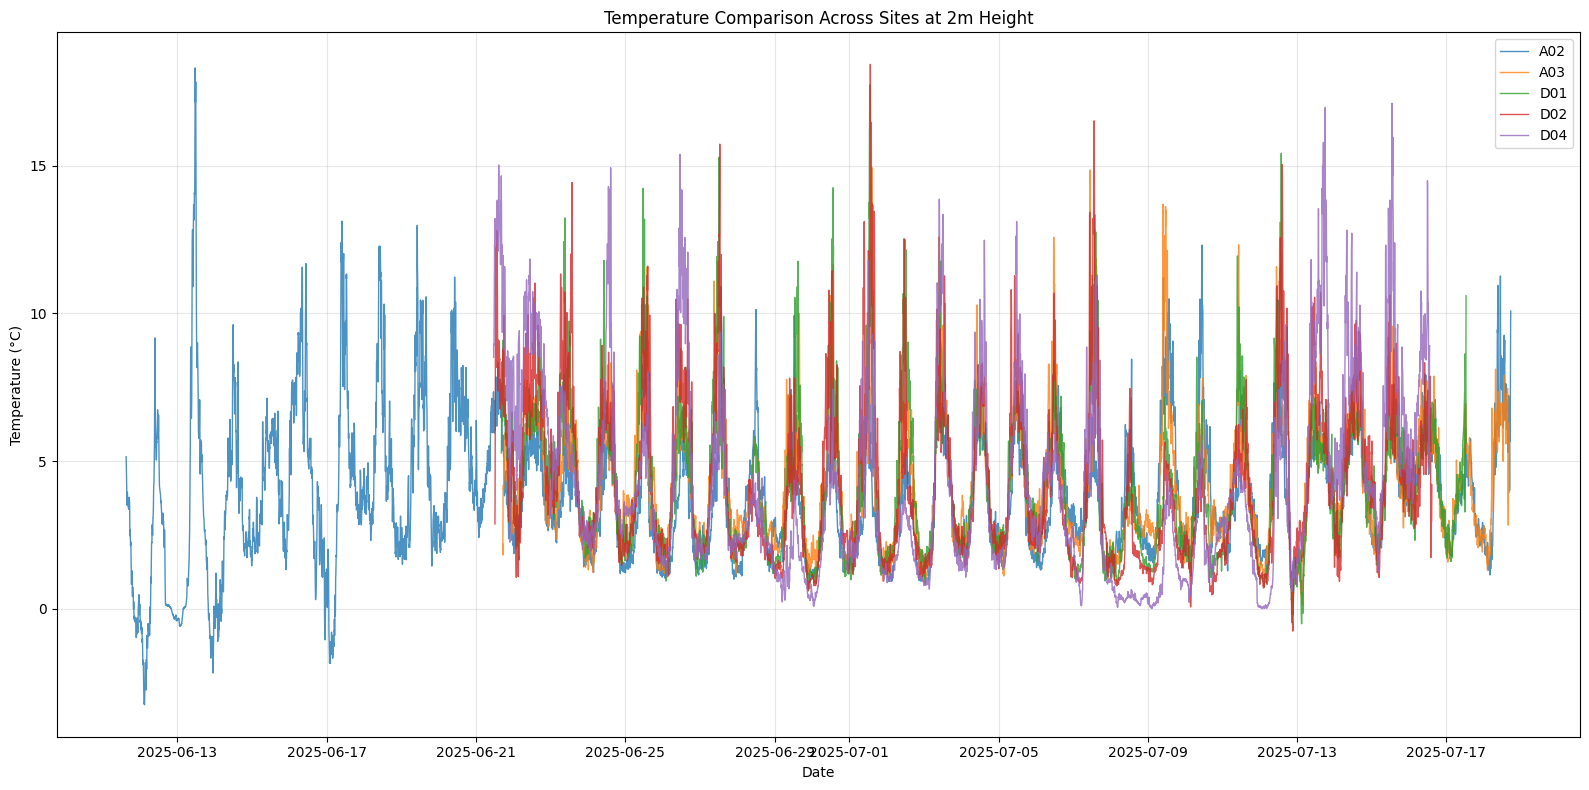

In [5]:
# Select multiple sites and compare at 2m height
comparison_sites = ["A02", "A03", "D01", "D02", "D04"]
height_to_compare = "2m"

# Filter for 2m sensors at specified sites
multi_site_data = ds["temp_c"].where(
    (ds.height == height_to_compare) & 
    (ds.site_id.isin(comparison_sites)), 
    drop=True
)

print(multi_site_data)

print(f"Comparing sites: {list(np.unique(multi_site_data.site_id.values))}")
print(f"Number of 2m sensors found: {len(multi_site_data.sensor_idx)}")

# Plot temperature data
fig, ax = plt.subplots(figsize=(16, 8))

# Group by site for plotting
for site in comparison_sites:
    site_sensors = multi_site_data.where(multi_site_data.site_id == site, drop=True)
    print(site_sensors)
    
    
    # If multiple sensors at same site/height, take the first one
    temp_data = site_sensors.isel(sensor_idx=0)
        
        
    ax.plot(temp_data.datetime, temp_data.values, 
            label=site, alpha=0.8, linewidth=1.0)

ax.set_title(f"Temperature Comparison Across Sites at {height_to_compare} Height")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 3: Data Selection and Filtering

Demonstrate various ways to select and filter the data using the new sensor_idx structure.

In [6]:
# Example data selections using sensor_idx structure
print("Various data selection examples:")

# 1. Select all 2m sensors across all sites
all_2m_data = ds.where(ds.height == "2m", drop=True)
print(f"1. All 2m sensors: {len(all_2m_data.sensor_idx)} sensors")

# 2. Select specific time period
time_slice = ds.sel(datetime=slice("2025-07-01", "2025-07-15"))
print(f"2. July 1-15 period: {time_slice.temp_c.shape}")

# 3. Select multiple specific sites using isin
multi_sites = ds.where(ds.site_id.isin(["A01", "A02", "A03"]), drop=True)
print(f"3. Sites A01, A02, A03: {len(multi_sites.sensor_idx)} sensors")

# 4. Select only shielded sensors
shielded_data = ds.where(ds.shielding == "shielded", drop=True)
print(f"4. Only shielded sensors: {len(shielded_data.sensor_idx)} sensors")

# 5. Select HOBO pendant sensors only
hobo_data = ds.where(ds.sensor_type == "hobo pendant", drop=True)
print(f"5. Only HOBO pendant sensors: {len(hobo_data.sensor_idx)} sensors")

# 6. Complex filtering: 2m shielded sensors at specific sites
complex_filter = ds.where(
    (ds.height == "2m") & 
    (ds.shielding == "shielded") & 
    (ds.site_id.isin(["A01", "A02", "A03"])), 
    drop=True
)
print(f"6. 2m shielded sensors at A01/A02/A03: {len(complex_filter.sensor_idx)} sensors")

# 7. Calculate statistics
print("\nSample statistics:")
print(f"Overall mean temperature: {ds.temp_c.mean(skipna=True).values:.2f}°C")
print(f"Temperature range: {ds.temp_c.min(skipna=True).values:.2f}°C to {ds.temp_c.max(skipna=True).values:.2f}°C")

# Site-based statistics using groupby (new pattern with sensor_idx)
print(f"Number of unique sites: {len(np.unique(ds.site_id.values))}")
print(f"Total number of sensors: {len(ds.sensor_idx)}")

Various data selection examples:
1. All 2m sensors: 35 sensors
2. July 1-15 period: (4320, 66)
3. Sites A01, A02, A03: 6 sensors
4. Only shielded sensors: 57 sensors
5. Only HOBO pendant sensors: 66 sensors
6. 2m shielded sensors at A01/A02/A03: 2 sensors

Sample statistics:
Overall mean temperature: 5.61°C
Temperature range: -6.39°C to 43.84°C
Number of unique sites: 33
Total number of sensors: 66


## Example 4: Data Temporal Coverage by Site and Sensor

Show the time periods when data is available for each sensor using the new structure.

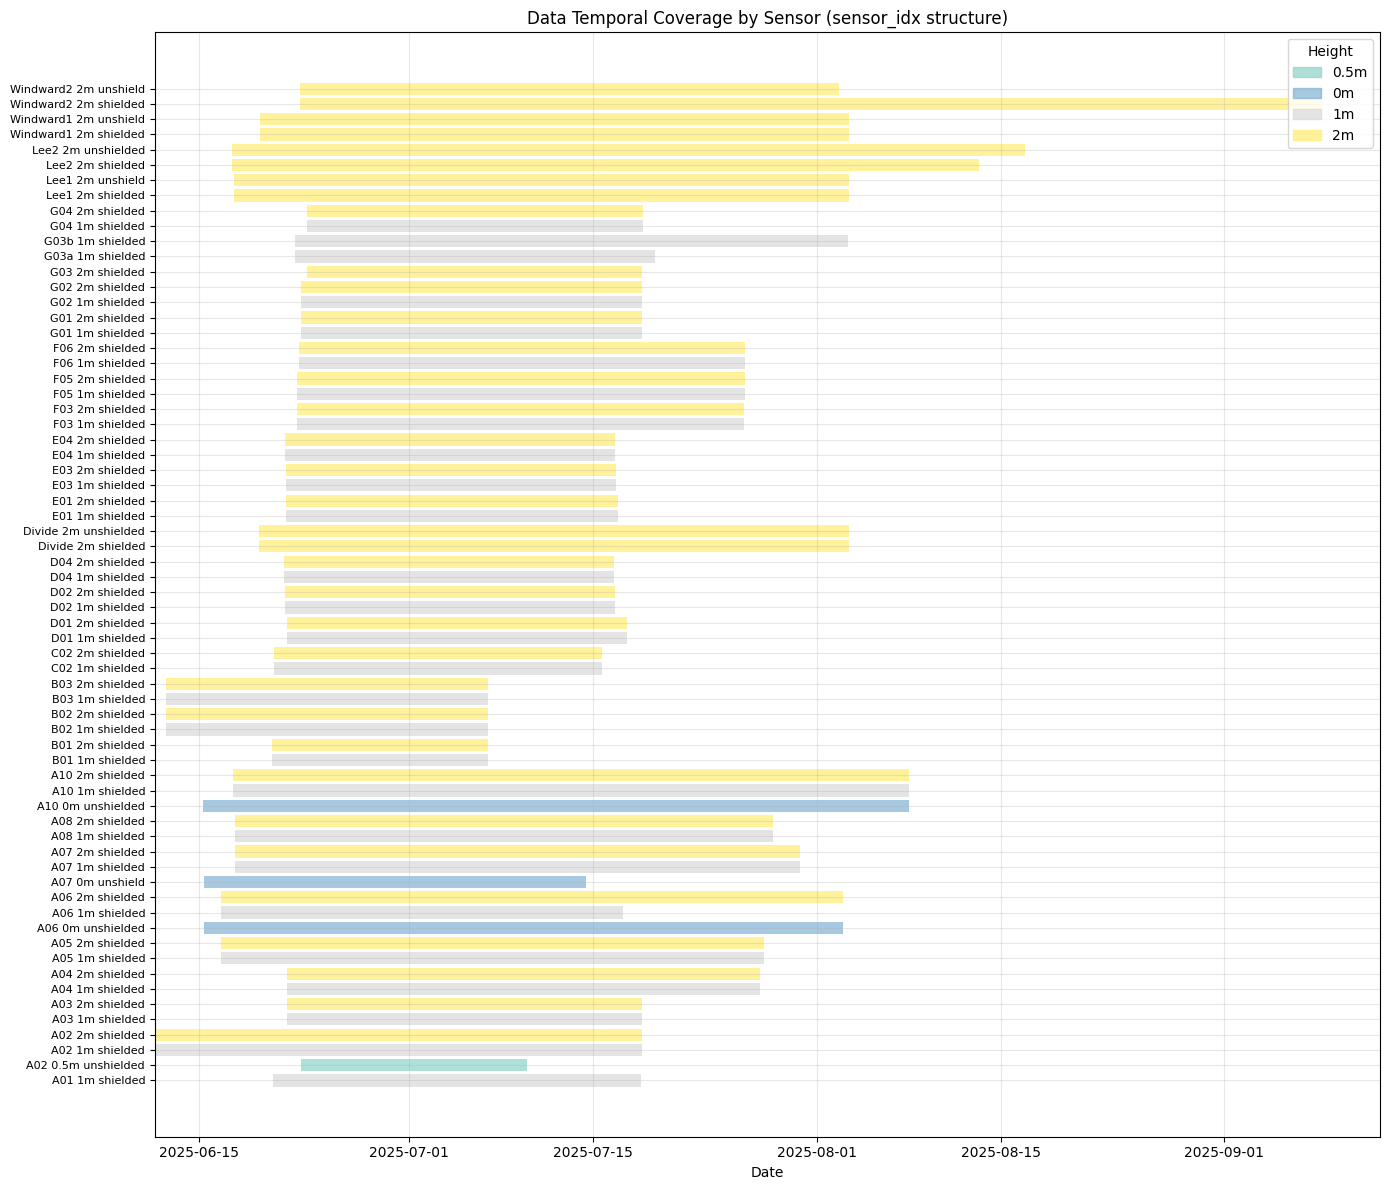


Data Coverage Summary by Sensor:
Site   Height   Shielding    Sensor ID    Start        End          Days   Points  
--------------------------------------------------------------------------------
A01    1m       shielded     22133645     06-20        07-18        28     8082    
A02    0.5m     unshielded   22038780     06-22        07-09        17     4948    
A02    1m       shielded     22133682     06-11        07-18        37     10686   
A02    2m       shielded     22133650     06-11        07-18        37     10686   
A03    1m       shielded     22133634     06-21        07-18        26     7768    
A03    2m       shielded     22133661     06-21        07-18        26     7768    
A04    1m       shielded     22133641     06-21        07-27        35     10362   
A04    2m       shielded     22133638     06-21        07-27        35     10363   
A05    1m       shielded     22133664     06-16        07-28        41     11897   
A05    2m       shielded     22133644     06-

In [7]:
# Calculate data time periods for each sensor
time_periods = []

for sensor_idx in range(len(ds.sensor_idx)):
    temp_data = ds.temp_c.isel(sensor_idx=sensor_idx)
    
    # Find first and last valid data points
    valid_data = temp_data.dropna("datetime")
    
    if len(valid_data) > 0:
        site_id = ds.site_id.values[sensor_idx]
        height = ds.height.values[sensor_idx]
        shielding = ds.shielding.values[sensor_idx]
        sensor_id = ds.sensor_id.values[sensor_idx]
        
        start_time = pd.Timestamp(valid_data.datetime.values[0])
        end_time = pd.Timestamp(valid_data.datetime.values[-1])
        duration_days = (end_time - start_time).days
        
        time_periods.append({
            'site_id': site_id,
            'height': height,
            'shielding': shielding,
            'sensor_id': sensor_id,
            'start_date': start_time,
            'end_date': end_time,
            'duration_days': duration_days,
            'data_points': len(valid_data)
        })

# Convert to DataFrame for easier visualization
periods_df = pd.DataFrame(time_periods)
periods_df = periods_df.sort_values(['site_id', 'height', 'shielding'])

# Create a timeline plot
fig, ax = plt.subplots(figsize=(14, 12))

# Create y-positions for each sensor
y_pos = {}
y_counter = 0
colors = plt.cm.Set3(np.linspace(0, 1, len(np.unique(periods_df['height']))))
height_colors = {height: colors[i] for i, height in enumerate(np.unique(periods_df['height']))}

for _, row in periods_df.iterrows():
    sensor_label = f"{row['site_id']} {row['height']} {row['shielding']}"
    if sensor_label not in y_pos:
        y_pos[sensor_label] = y_counter
        y_counter += 1
    
    # Plot the time period as a horizontal bar
    ax.barh(
        y_pos[sensor_label], 
        (row['end_date'] - row['start_date']).total_seconds() / (24 * 3600),  # Duration in days
        left=row['start_date'], 
        height=0.8,
        color=height_colors[row['height']], 
        alpha=0.7
    )

# Formatting
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax.set_xlabel("Date")
ax.set_title("Data Temporal Coverage by Sensor (sensor_idx structure)")
ax.grid(True, alpha=0.3)

# Create legend for heights
handles = [plt.Rectangle((0,0),1,1, color=height_colors[height], alpha=0.7) for height in np.unique(periods_df['height'])]
ax.legend(handles, np.unique(periods_df['height']), title="Height", loc='upper right')

plt.tight_layout()
plt.show()

# Print summary table
print("\nData Coverage Summary by Sensor:")
print("=" * 80)
print(f"{'Site':<6} {'Height':<8} {'Shielding':<12} {'Sensor ID':<12} {'Start':<12} {'End':<12} {'Days':<6} {'Points':<8}")
print("-" * 80)
for _, row in periods_df.head(15).iterrows():  # Show first 15 entries
    print(f"{row['site_id']:<6} {row['height']:<8} {row['shielding']:<12} {row['sensor_id']:<12} "
          f"{row['start_date'].strftime('%m-%d'):<12} {row['end_date'].strftime('%m-%d'):<12} "
          f"{row['duration_days']:<6} {row['data_points']:<8}")

if len(periods_df) > 15:
    print(f"... and {len(periods_df) - 15} more sensors")

# Summary statistics
print(f"\nOverall Summary:")
print(f"Total sensors with data: {len(periods_df)}")
print(f"Unique sites: {len(periods_df['site_id'].unique())}")
print(f"Average deployment duration: {periods_df['duration_days'].mean():.1f} days")
print(f"Longest deployment: {periods_df['duration_days'].max()} days")
print(f"Shortest deployment: {periods_df['duration_days'].min()} days")

## Next Steps

This notebook demonstrates the basic data access patterns for the JIFLR pendant data using the **new sensor_idx structure**. Key advantages of this structure:

## New Analysis Patterns

```python
# Get all sensors at a site
site_data = ds.where(ds.site_id == 'A01', drop=True)

# Get sensors at specific height  
height_data = ds.where(ds.height == '2m', drop=True)

# Get specific sensor configuration
sensor = ds.where((ds.site_id == 'A01') & (ds.height == '2m') & (ds.shielding == 'shielded'), drop=True)

# Multiple site selection
multi_site = ds.where(ds.site_id.isin(['A01', 'A02', 'A03']), drop=True)
```

You can extend these examples for:

1. **Advanced lapse rate calculations** using elevation data and height differences
2. **Spatial interpolation** between sites using site coordinates
3. **Diurnal cycle analysis** with groupby operations
4. **Cross-sensor correlation analysis** 
5. **Integration with pace data** from intensive sites
6. **Export to other formats** for further analysis

The clean sensor_idx structure makes all these analyses more straightforward and memory-efficient.

In [8]:
# Close the dataset
ds.close()
print("Analysis complete!")

Analysis complete!
